# 학습 관련 기술들

이번 장에서는 신경망 학습의 핵심 개념들을 살펴봄   
- 가중치 매개변수의 최적값을 탐색하는 최적화 방법
- 가중치 매개변수 초깃값
- 하이퍼파라미터 설정 방법 등
- 오버피팅의 대응책인 가중치 감소와 드롭아웃 등의 정규화 방법
- 배치 정규화

이번 장에서 설명하는 기법을 이용하면 신경망(딥러닝) 학습의 효율과 정화도를 높일 수 있음

## 매개변수 갱신

신경망 학습의 목적은 손실 함수의 값을 가능한 한 낮추는 매개변수를 찾는 것   
이는 곧 매개변수의 최적값을 찾는 문제 - 이런 문제를 푸는 것을 **최적화(optimization)** 이라 함

매개변수 공간은 매우 넓고 복잡해서 최적의 솔루션 찾기는 매우 어려운 문제   
수식을 풀어 순식간에 최솟값을 구하는 방법은 없음   
심층 신경망에서는 매개변수의 수가 엄청나게 많아져서 문제는 더욱 심각해짐

지금까지 최적의 매개변수 값을 찾는 단서로 매개변수의 기울기(미분)를 이용했음   
매개변수의 기울기를 구해, 기울어진 방향으로 매개변수 값을 갱신하는 일을 계속 반복해서 점점 최적의 값에 다가감 - **확률적 경사 하강법(SGD)** 이란 단순한 방법   

SGD는 매개변수 공간을 무작정 찾는 것보다 '똑똑한' 방법   
SGD는 단순하지만, (문제에 따라서는) SGD보다 똑똑한 방법도 있음   
이제부터 SGD의 단점을 알아보고 다른 최적화 기법을 알아봄

### 모험가 이야기

최적화를 해야하는 상황을 모험가 이야기에 비유

> 색다른 모험가가 있습니다. 광활한 메마른 산맥을 여행하면서 날마다 깊은 골짜기를 찾아 발걸음을 옮깁니다. 그는 전설에 나오는 세상에서 가장 깊고 낮은 골짜기, '깊은 곳'을 찾악가려 합니다. 그것이 그의 여행 목적이죠. 게다가 그는 엄격한 '제약' 2개로 자신을 옭아맸습니다. 하나는 지도를 보지 않을 것, 또 하나는 눈가리개를 쓰는 것입니다. 지도도 없고 보이지도 않으니 가장 낮은 골짜기가 광대한 땅 어디에 있는지 알 도리가 없죠. 그런 혹독한 조건에서 이 모험가는 어떻게 '깊은 곳'을 찾을 수 있을까요? 어떻게 걸음을 옮겨야 효율적으로 '깊은 곳'을 찾아낼 수 있을까요?

이 어려운 상황에서 중요한 단서가 되는 것이 땅의 '기울기'   
지금 서 있는 장소에서 가장 크게 기울어진 방향으로 가자는 것이 SGD의 전략   
이 일을 반복하면 언젠가 '깊은 곳'에 찾아갈 수 있을지도 모름

### 확률적 경사 하강법(SGD)

SGD를 수식으로 쓰면   
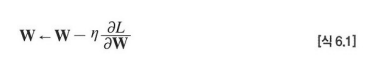   
- 여기서 W는 갱신할 가중치 매개변수고 은 W에 대한 손실 함수의 기울기
- 는 학습률을 의미하는데, 실제로는 0.01이나 0.001과 같은 값을 미리 정해서 tkdydgka
- <-는 우변의 값으로 좌변의 값을 갱신한다는 뜻
- 식에서 보듯 SGD는 기울어진 방향으로 일정 거리만 가겠다는 단순한 방법

이 SGD를 파이썬 클래스로 구현

In [2]:
class SGD:
    def __init__(self, lr=0.01):
        self.lr = lr
    
    def update(self, params, grads):
        for key in params.keys():
            params[key] -= self.lr * grads[key]

- 초기화 때 받는 인수인 lr은 learning rate(학습률)를 뜻함
- 이 학습률을 인스턴스 변수로 유지
- update(params, grads) 메서드는 SGD 과정에서 반복해서 불림
- 인수인 params와 grads는 (지금까지으 신경망 구현과 마찬가지로) 딕셔너리 변수
- params['W1'], grads['W1'] 등과 같이 각각 가중치 매개변수와 기울기를 저장하고 있음

SGD 클래스를 사용하면 신경망 매개변수의 진행을 다음과 같이 수행할 수 있음 (다음 코드는 실제로는 동작하지 않는 의사 코드)

In [7]:
# import sys, os
# sys.path.append(os.pardir)
# from two_layer_net import TwoLayerNet

# network = TwoLayerNet(...)
# optimizer = SGD()

# for i in range(10000):
#     ...
#     x_batch, t_batch = get_mini_batch(...)  # 미니배치
#     grads = network.gradient(x_batch, t_batch)
#     params = network.params
#     optimizer.update(params,grads)
#     ...

- optimizer는 '최적화를 행하는 자'라는 뜻의 단어 - 이 코드에서는 SGD가 그 역할을 함
- 매개변수 갱신을 optimizer가 책임지고 수행함 -> 우리는 optimizer에 매개변수와 기울기 정보만 넘겨주면 됨

이처럼 최적화를 담당하는 클래스를 분리해 구현하면 기능을 모듈화하기 좋음
- 예를 들어 모멘텀이라는 최적화 기법 역시 update(params, grads)라는 공통의 메서드를 갖도록 구현함
- 그때 optimizer = SGD()를 optimizer = Momentum()으로만 변경하면 됨

> 대부분의 딥러닝 프레임워크는 다양한 최적화 기법을 구현해 제공하며, 원하는 기법으로 쉽게 바꿀 수 있는 구조로 되어 있음   
> 예를 들어 Lasagne이라는 딥러닝 프레임워크는 다양한 최적화 기법 구현해 updates.py 파일에 함수로 정리해둠   
> 사용자는 그중 쓰고 싶은 기법을 선택할 수 있음

### SGD의 단점

SGD는 단순하고 구현도 쉽지만, 문제에 따라서 비효율적일 때가 있음

이번 절에서는 SGD의 단점을 알아보고 다음 함수의 최솟값을 구하는 문제를 생각해봄   
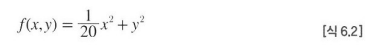   
- 위 함수는 아래 그림의 왼쪽과 같이 '밥그릇'을 x축 방향으로 늘인 듯한 모습이고, 실제로 그 등고선은 오른쪽과 같이 x축 방향으로 늘인 타원으로 되어 있음   
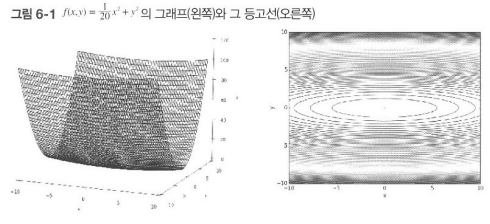   
- 위 함수의 기울기를 그려보면   
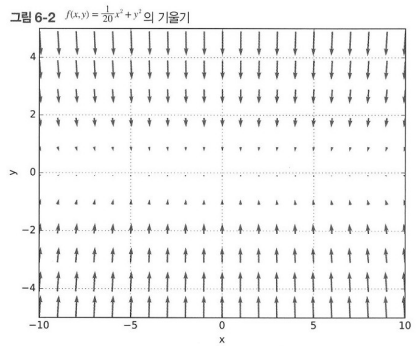   
- 이 기울기는 y축 방향은 크고 x축 방향은 작다는 것이 특징 - y축은 가파른데 x축 방향은 완만한 것
- 여기서 주의할 점으로는 위 함수가 최솟값이 되는 장소는 (x, y) = (0, 0)이지만, 그림이 보여주는 기울기 대부분은 (0, 0) 방향을 가리키지 않는다는 것

이제 그림 6-1의 함수에 SGD를 적용해보면   
탐색을 시작하는 장소(초깃값)는 (x, y) = (-7.0, 2.0)으로

결과는   
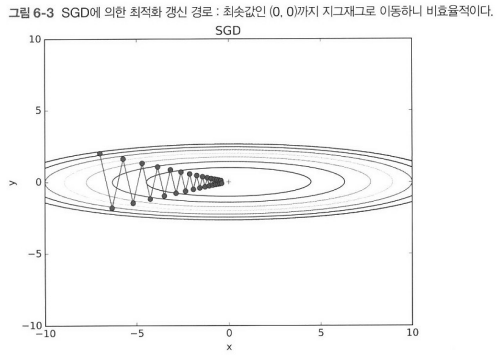   
- SGD는 그리과 같이 심하게 굽이진 움직임을 보여줌 - 상당히 비효율적인 움직임
- 즉, SGD의 단점은 비등방성(anisotropy) 함수(방향에 따라 성질, 즉 여기에서는 기울기가 달라지는 함수)에서는 탐색 경로가 비효율적이라는 것
- 이럴 때는 SGD 같이 무작정 기울어진 방향으로 진행하는 단순한 방식보다 더 영리한 묘안이 필요함
- 또한, SGD가 지그재그로 탐색하는 근본 원인은 기울어진 방향이 본래의 최솟값과 다른 방향을 가리켜서라는 점도 생각해볼 필요가 있음

SGD의 이런 단점을 개선해주는 모멘텀, AdaGrad, Adam이라는 세 방법을 알아보기   
이들은 모두 SGD를 대체하는 기법으로, 각각을 간단히 설명하면서 수시과 파이썬 구현을 살펴봄

### 모멘텀

**모멘텀(Momentum)** 은 '운동량'을 뜻하는 단어로, 물리와 관계가 있음

모멘텀 기법은 수식으로는   
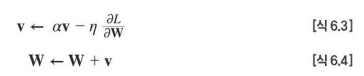   
- 전에 SGD처럼 여기에서도 W는 갱신할 가중치 매개변수, 은 W에 대한 손실함수의 기울기, 는 학습률
- v라는 변수가 새로 나옴 - 이는 물리에서 말하는 속도(velocity)에 해당
- 모멘텀 식은 기울기 방향으로 힘을 받아 물체가 가속된다는 물리 법칙을 나타냄
- 모멘텀은 다음과 같이 공이 그릇의 바닥을 구르는 듯한 움직임을 보여줌   
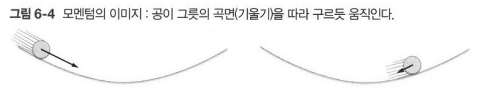   
- 또, 식의 항은 물체가 아무런 힘을 받지 않았을 때 서서히 하강시키는 역할을 함 (는 0.9 등의 값으로 설정함)
- 물리에서의 지면 마찰이나 공기 저항에 해당

모멘텀을 구현해보면

In [8]:
import numpy as np

class Momentum:
    def __init__(self, lr=0.01, momentum=0.9):
        self.lr = lr
        self.momentum = momentum
        self.v = None
    
    def update(self, params, grads):
        if self.v is None:
            self.v = {}
            for key, val in params.items():
                self.v[key] = np.zeros_like(val)
        
        for key in params.keys():
            self.v[key] = self.momentum*self.v[key] - self.lr*grads[key]
            params[key] += self.v[key]

- 인스턴스 변수 v가 물체의 속도
- v는 초기화 때는 아무 값도 담지 않고, 대신 update()가 처음 호출될 때 매개변수와 같은 구조의 데이터를 딕셔너리 변수로 저장함
- 나머지 부분은 모멘텀 식을 간단히 코드로 옮긴 것

이제 모멘텀을 사용해서 최적화 문제를 풀어보면 결과는   
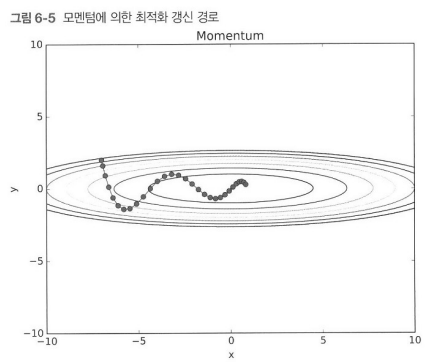   
- 그림에서 보듯 모멘텀의 갱신 경로는 공이 그릇 바닥을 구르듯 움직임 - SGD와 비교하면 '지그재그 정도'가 덜함
- 이는 x축의 힘ㅇ느 아주 작지만 방향은 변하지 않아서 한 방향으로 일정하게 가속하기 때문
- 거꾸로 y축의 힘은 크지만 위아래로 번갈아 받아서 상충하여 y축 방향의 속도는 안정적이지 않음
- 전체적으로는 SGD보다 x축 방향으로 빠르게 다가가 지그재그 움직임이 줄어듬

### AdaGrad

신경망 학습에서는 학습률(수식에서는 ) 값이 중요   
이 값이 너무 작으면 학습 시간이 너무 길어지고, 반대로 너무 크면 발상하여 학습이 제대로 이뤄지지 않음   

이 학습률을 정하는 효과적 기술로 **학습률 감소(learning rate decay)** 가 있음   
이는 학습을 진행하면서 학습률을 점차 줄여가는 방법   
처음에는 크게 학습하다가 조금씩 작게 학습한다는 것으로, 실제 신경망 학습에 자주 쓰임

학습률을 서서히 낮추는 가장 간단한 방법은 매개변수 '전체'의 학습률 값을 일괄적으로 낮추는 것   
이를 더욱 발전시킨 것이 AdaGrad   
AdaGrad는 '각각의' 매개변수에 '맞춤형'값을 만들어줌

AdaGrad는 개별 매개변수에 적응적으로(adaptive) 학습률을 조정하면서 학습을 진행함   
AdaGrad의 갱신 방법은 수식으로는   
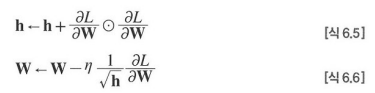   
- 마찬가지로 W는 갱신할 가중치 매개변수, 은 W에 대한 손실함수의 기울기, 는 학습률을 뜻함
- 여기에서는 h라는 변수가 새로 등장
- h는 식에서 보듯 기존 기울기 값을 제곱하여 계속 더해줌 (기호는 행렬의 원소별 곱셈을 의미)
- 그리고 매개변수를 갱신할 때 을 곱해 학습률을 조정함
- 매개변수의 원소 중에서 많이 움직인(크게 갱신된) 원소는 학습률이 낮아진다는 뜻 - 다시 말해 학습률 갑소가 매개변수의 원소마다 다으게 적용됨을 뜻함

> AdaGrad는 과거의 기울기를 제곱하여 계속 더해감   
> 그래서 학습을 진행할수록 갱신 강도가 약해짐. 실제로 무한히 계속 학습한다면 어느 순간 갱신량이 0이 되어 전혀 갱신하지 않게 됨   
> 이 문제를 개선한 기법으로서 RMSProp이라는 방법이 있음   
> RMSProp은 과거의 모든 기울기를 균일하게 더해가는 것이 아니라, 먼 과거의 기울기는 서서히 잊고 새로운 기울기 정보를 크게 반영함   
> 이를 **지수이동평균(Exponentioal Moving Average, EMA)** 이라 하여, 과거 기울기의 반영 규모를 기하급수적으로 감소시킴

AdaGrad를 구현하기

In [10]:
class AdaGrad:
    def __init__(self, lr=0.01):
        self.lr = lr
        self.h = None
    
    def update(self, params, grads):
        if self.h is None:
            self.h = {}
            for key, val in params.items():
                self.h[key] = np.zeros_like(val)
        
        for key in params.keys():
            self.h[key] += grads[key] * grads[key]
            params[key] -= self.lr * grads[key] / np.sqrt(self.h[key] + 1e-7)

- 여기에서 주의할 것은 마지막 줄에서 1e-7이라는 작은 값을 더하는 부분
- 이 작은 값은 self.h[key]에 0이 담겨 있다 해도 0으로 나누는 사태를 막아줌
- 대부분의 딥러닝 프레임워크에서는 이 값도 인수로 설정할 수 있음

그럼 AdaGrad를 사용해서 최적화 문제를 풀어보면   
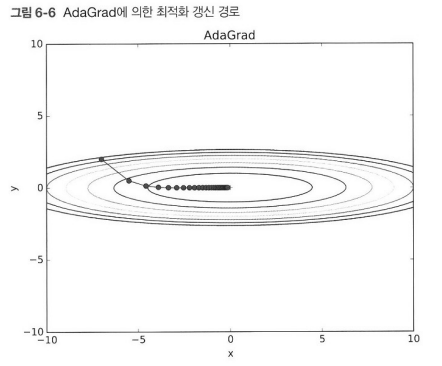   
- 그림을 보면 최솟값을 향해 효율적으로 움직이는 것을 알 수 있음
- y축 방향은 기울기가 커서 처음에는 크게 움직이지만, 그 큰 움직임에 비례해 갱신 정도도 큰 폭으로 작아지도옥 조정됨
- 그래서 y축 방향으로 갱신 강도가 빠르게 약해지고, 지그재그 움직임이 줄어듬

### Adam

모멘텀은 공이 그릇 바닥을 구르는 듯한 움직임을 보이고, AdaGrad는 매개변수의 원소마다 적응적으로 갱신 정도를 조정함   
이 두 기법을 융합한다는 생각에서 출발한 것이 Adam

Adam은 2015년에 제안된 새로운 방법으로, 그 이론은 다소 복잡하지만 직관적으로는 모멘텀과 AdaGrad를 융합한 듯한 방법   
이 두 방법의 이점을 조합했다면 매개변수 공간을 효율적으로 탐색해줄 것으로 기대 가능   
또, 하이퍼파라미터의 '편향 보정'이 진행된다는 점도 Adam의 특징   
여기에서는 더 깊이 파고들지 않음 - 궁금하면 원논문을 참고   

그럼 Adam을 사용해 최적화 문제를 풀어보면   
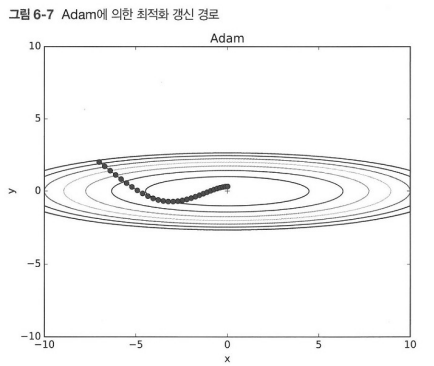   
- 그림과 같이 Adam 갱신 과정도 그릇 바닥을 구르듯 움직임
- 모멘텀과 비슷한 패턴인데, 모멘텀 때보다 공의 좌우 흔들림이 적음
- 이는 학습의 갱신 강도를 적응적으로 조정해서 얻은 혜택

> Adam은 하이퍼파라미터를 3개 설정함   
> 하나는 지금까지의 학습률(논문에서는 로 등장)   
> 나머지 두 개는 일차 모멘텀용 계수 과 이차 모멘텀용 계수    
> 논문에 따르면 기본 설정값은 은 0.9, 은 0.999이며,   
> 이 값이면 많은 경우에 좋은 결과를 얻을 수 있음

In [11]:
class Adam:

    """Adam (http://arxiv.org/abs/1412.6980v8)"""

    def __init__(self, lr=0.001, beta1=0.9, beta2=0.999):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.iter = 0
        self.m = None
        self.v = None
        
    def update(self, params, grads):
        if self.m is None:
            self.m, self.v = {}, {}
            for key, val in params.items():
                self.m[key] = np.zeros_like(val)
                self.v[key] = np.zeros_like(val)
        
        self.iter += 1
        lr_t  = self.lr * np.sqrt(1.0 - self.beta2**self.iter) / (1.0 - self.beta1**self.iter)         
        
        for key in params.keys():
            #self.m[key] = self.beta1*self.m[key] + (1-self.beta1)*grads[key]
            #self.v[key] = self.beta2*self.v[key] + (1-self.beta2)*(grads[key]**2)
            self.m[key] += (1 - self.beta1) * (grads[key] - self.m[key])
            self.v[key] += (1 - self.beta2) * (grads[key]**2 - self.v[key])
            
            params[key] -= lr_t * self.m[key] / (np.sqrt(self.v[key]) + 1e-7)
            
            #unbias_m += (1 - self.beta1) * (grads[key] - self.m[key]) # correct bias
            #unbisa_b += (1 - self.beta2) * (grads[key]*grads[key] - self.v[key]) # correct bias
            #params[key] += self.lr * unbias_m / (np.sqrt(unbisa_b) + 1e-7)


### 어느 갱신 방법을 이용할 것인가?

지금까지 매개변수의 갱신 방법 4개를 살펴봄

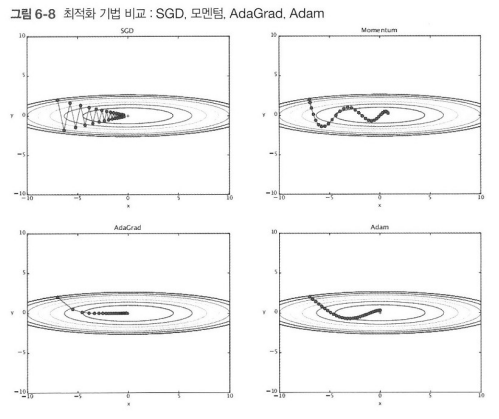   
- 그림과 같이 사용한 기법에 따라 갱신 경로가 다름
- 이 그림만 보면 AdaGrad가 가장 나아보이지만, 사실 그 결과는 풀어야 할 문제가 무엇이냐에 따라 달라지므로 주의해야 함
- 또, 당연하지만 (학습률 등의) 하이퍼파라미터를 어떻게 설정하느냐에 따라서도 결과가 바뀜

SGD, 모멘텀, AdaGrad, Adam 네 가지 중 어떤 것을 채택하면 될까?   
모든 문제에서 항상 뛰어난 기법이라는 것은 (아직까진) 없음   
각자의 장단이 있어 잘 푸는 문제와 서툰 문제가 있음

많은 연구에서 SGD를 사용하고 있고, 모멘텀과 AdaGrad도 시도해볼 만한 가치가 충분함   
이 책에서는 주오 SGD와 Adam을 사용하지만, 각자의 상황을 고려해 여러 가지로 시도해봐야 함

### MNIST 데이터셋으로 본 갱신 방법 비교

손글씨 숫자 인식을 대상으로 네 기법을 비교

각 방법의 학습 진도가 얼마나 다른지를 그려보면   
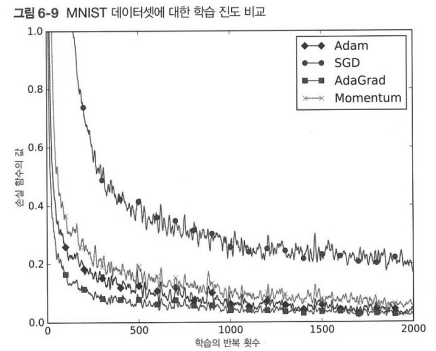   
- 이 실험은 각 층이 100개의 뉴런으로 구성된 5층 신경망에서 ReLU를 활성화 함수로 사용해 측정한 결과
- 결과를 보면 SGD의 학습 진도가 가장 느림
- 나머지 세 기법의 진도는 비슷한데, 잘 보면 AdaGrad가 조금 더 빠름
- 이 실험에서 주의할 점은 하이퍼파라미터인 학습률과 신경망의 구조(층 깊이 등)에 따라 결과가 달라진다는 점
- 다만 일반적으로 SGD보다 다른 세 기법이 빠르게 학습하고, 때로는 최종 정확도도 높게 나타남

## 가중치의 초깃값

신경망 학습에서 특히 중요한 것이 가중치의 초깃값 - 가중치의 초깃값을 무엇으로 설정하느냐가 신경망 학습의 성패를 가르는 일이 실제로 자주 있음   
이번 절에서는 권장 초깃값에 대해 설명하고 실험을 통해 실제로 신경망 학습이 신속하게 이뤄지는 모습을 확인함

### 초깃값을 0으로 하면?

**가중치 갑소(weight decay)** 기법: 오버피팅을 억제해 범용 성능을 높이는 테크닉   
가중치 감소 - 간단히 말하면 가중치 매개변수의 값이 작아지도록 학습하는 방법, 가중치 값을 작게 하여 오버피팅이 일어나지 않게 하는 것   

가중치를 작게 만들고 싶으면 초깃값도 최대한 작은 값에서 시작하는 것이 정공법   
지금까지 가중치의 초깃값은 0.01 * np.random.randn(10, 100) 처럼 정규분포에서 생성되는 값을 0.01배 한 작은 값(표준편차가 0.01인 정규분포)를 사용함   

그렇다면 가중치의 초깃값을 0으로 설정하면?   
답부터 얘기하면, 실제로 학습이 올바로 이뤄지지 않음

그 이유는?   
정확히는 가중치를 균일한 값으로 설정해서는 안됨   
그 이유는 오차역전파법에서 모든 가중치의 값이 똑같이 갱신되기 때문   
- 예를 들어 2층 신경망에서 첫 번째와 두 번째 층의 가중치가 0이라고 가정하면   
- 순전파 때는 입력층의 가중치가 0이기 때문에 두 번째 층의 뉴런에 모두 같은 값이 전달됨
- 두 번째 층의 모든 뉴런에 같은 값이 입력된다는 것은 역전파 때 두 번째 층의 가중치가 모두 똑같이 갱신된다는 말이 됨 ('곱셈 노드의 역전파'를 떠올려보면됨)
- 그래서 가중치들은 같은 초깃값에서 시작하고 갱신을 거쳐도 여전히 같은 값을 유지하는 것
- 이는 가중치를 여러 개 갖는 의미를 사라지게 함
- 이 '가중치가 고르게 되어버리는 상황'을 막으려면 (정확히는 가중치의 대칭적인 구조를 무너뜨리려면) 초깃값을 무작위로 설정해야 함

### 은닉층의 활성화값 분포

은닉층의 활성화값(활성화 함수의 출력 데이터)의 분포를 관찰하면 중요한 정보를 얻을 수 있음   
이번 절에서는 가중치의 초깃값에 따라 은닉층 활성화값들이 어떻게 변화하는지 간단한 실험을 해봄   
구체적으로는 활성화 함수로 시그모이드 함수를 사용하는 5층 신경망에 무작위로 생성한 입력 데이터를 흘리며 각 층의 활성화값 분포를 히스토그램으로 그려봄   

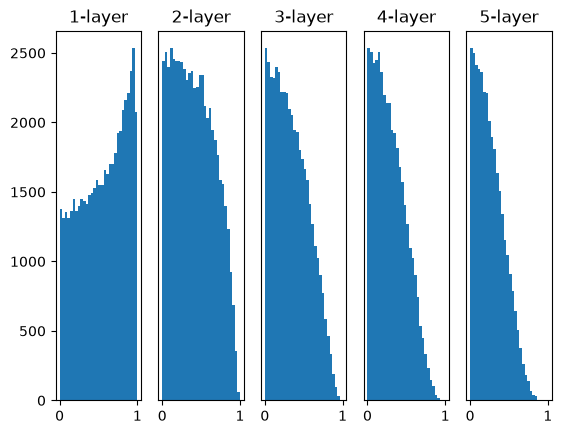

In [21]:
# coding: utf-8
import numpy as np
import matplotlib.pyplot as plt


def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def ReLU(x):
    return np.maximum(0, x)


def tanh(x):
    return np.tanh(x)
    
input_data = np.random.randn(1000, 100)  # 1000개의 데이터
node_num = 100  # 각 은닉층의 노드(뉴런) 수, 앞 층의 노드 수
hidden_layer_size = 5  # 은닉층이 5개
activations = {}  # 이곳에 활성화 결과를 저장

x = input_data

for i in range(hidden_layer_size):
    if i != 0:
        x = activations[i-1]

    # 초깃값을 다양하게 바꿔가며 실험해보기
    # w = np.random.randn(node_num, node_num) * 1
    # w = np.random.randn(node_num, node_num) * 0.01
    w = np.random.randn(node_num, node_num) * np.sqrt(1.0 / node_num)
    # w = np.random.randn(node_num, node_num) * np.sqrt(2.0 / node_num)

    a = np.dot(x, w)

    # 활성화 함수도 바꿔가며 실험해보기
    # z = sigmoid(a)
    # z = ReLU(a)
    z = tanh(a)

    activations[i] = z

# 히스토그램 그리기
for i, a in activations.items():
    plt.subplot(1, len(activations), i+1)
    plt.title(str(i+1) + "-layer")
    if i != 0: plt.yticks([], [])
    # plt.xlim(0.1, 1)
    # plt.ylim(0, 7000)
    plt.hist(a.flatten(), 30, range=(0,1))
plt.show()

- 층이 5개가 있으며, 각 층의 뉴런은 100개씩
- 입력 데이터로서 1,000개의 데이터를 정규분포로 무작위로 생성하여 이 5층 신경망에 흘림
- 활성화 함수로는 시그모이드 함수를 이용했고, 각 층의 활성화 결과를 activations 변수에 저장함
- 이 코드에서는 가중치의 분포에 주의해야 함
- 처음에는 표준편차가 1인 정규분포를 이용했는데, 이 분포된 정도(표준 편차)를 바꿔가며 활성화값들의 분포가 어떻게 변화하는지 관찰하는 것이 이 실험의 목적

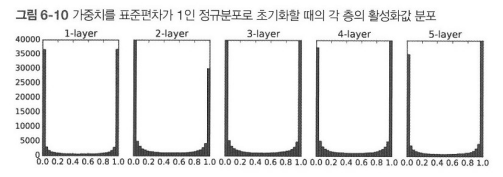   
- 각 층의 활성화값들이 0과 1에 치우쳐 분포되어 있음
- 시그모이드 함수는 그 출력이 0에 가까워지자(또는 1에 가까워지자) 그 미분은 0에 다가감
- 그래서 데이터가 0과 1에 치우쳐 분포하게 되면 역전파의 기울기 값이 점점 작아지다가 사라짐 - **기울기 소실(gradient vanishing)** 
- 층을 깊게 하는 딥러닝에서는 기울기 소실은 더 심각한 문제가 될 수 있음

가중치의 표준편차를 0.01로 바꿔 다시 해보면   
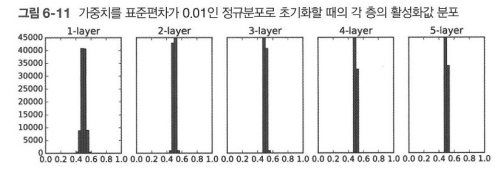   
- 이번에는 0.5 부근에 집중됨
- 앞선 경우처럼 0과 1로 치우치진 않았으니 기울기 소실 문제는 일어나지 않지만, 활성화값들이 치우쳤다는 것은 표현력 관점에서는 큰 문제가 있는 것
- 이 상화에서는 다수의 뉴런이 거의 같은 값을 출력하고 있으니 뉴런을 여러 개 둔 의미가 없어진다는 뜻
    - 예를 들어 뉴런 100개가 거의 같은 값을 출력한다면 뉴런 1개짜리와 별반 다를 게 없는 것
- 그래서 활성화값들이 치우치면 **표현력을 제한** 한다는 관점에서 문제가 생김

> 각 층의 활성화값은 적당히 고루 분포되어야 함   
> 층과 층 사이에 적당하게 다양한 데이터가 흐르게 해야 신경망 학습이 효율적으로 이뤄지기 때문   
> 반대로 치우친 데이터가 흐르면 기울기 소실이나 표현력 제한 문제에 빠져서 학습이 잘 이뤄지지 않는 경우가 생김

이어서 사비에르 글로로트와 오슈아 벤지오의 논문에서 권장하는 가중치 초깃값인 **Xavier 초깃값** 을 사용해보기   
Xavier 초깃값은 일반적인 딥러닝 프레임워크들이 표준적으로 이용하고 있음   
- 예를 들어 카페(caffe) 프레임워크는 가중치 초깃값을 설정할 때 인수로 xavier를 지정할 수 있음

이 논문은 각 층의 활성화값들을 광범위하게 분포시킬 목적으로 가중치의 적절한 분포를 찾고자 했음   
그리고 앞 계층의 노드가 n개라면 표준편차가 인 분포를 사용하면 된다는 결론을 이끌었음   
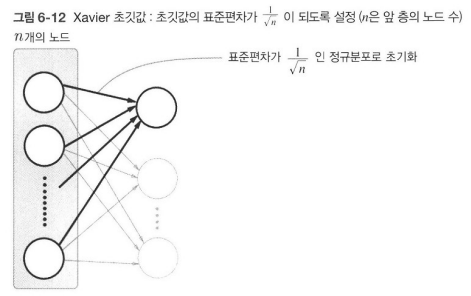   
- Xavier 초깃값을 사용하면 앞 층에 노드가 많을수록 대상 노드의 초깃값으로 설정하는 가중치가 좁게 퍼짐   

실제로 실습해보면 (위 코드에서 w = np.random.randn(node_num, node_num) * np.sqrt(1.0 / node_num) 사용)   
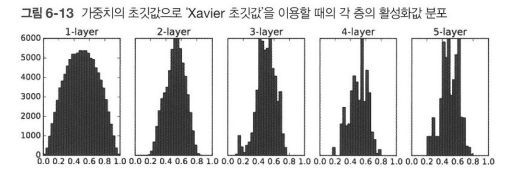   
- 결과를 보면 층이 깊어지면서 형태가 다소 일그러지지만, 앞에서 본 방식보다는 확실히 넓게 분포됨을 알 수 있음   
- 각 층에 흐르는 데이터는 적당히 퍼져 있으므로, 시그모이드 함수의 표현력도 제한받지 않고 학습이 효율적으로 이뤄질 것으로 기대됨

> 위 그림은 오른쪽으로 갈수록 약간씩 일그러지고 있음   
> 이 일그러짐은 sigmoid 함수 대신 tanh 함수(쌍곡선 함수)를 이용하면 개선됨 - 실제로 tanh 함수를 이용하면 말끔한 종 모양으로 분포됨   
> 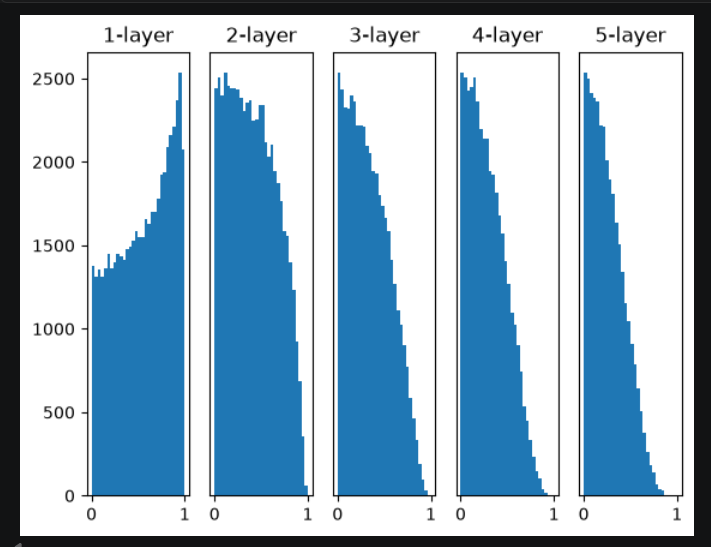   
> tanh 함수도 sigmoid 함수와 같은 'S'자 모양 곡선 함수   
> 다만 tanh 함수가 원점(0,0)에서 대칭인 S곡선인 반면, sigmoid 함수는 (x,y)=(0,0.5)에서 대칭인 S곡선   
> 활성화 함수용으로는 원점에서 대칭인 함수가 바람직하다고 알려져 있음   


### ReLU를 사용할 때의 가중치 초깃값

Xavier 초깃값은 활성화 함수가 선형인 것을 전제로 이끈 결과   
- sigmoid 함수와 tanh 함수는 좌우 대칭이라 중앙 부근이 선형인 함수로 볼 수 있음 - Xavier 초깃값이 적당

반면 ReLU를 이용할 때는 ReLU에 특화된 초깃값을 이용하라고 권장 - 초깃값을 찾아낸 카이밍 히의 이름을 따 **He 초깃값** 이라 함   
- HE 초깃값은 앞 계층의 노드가 n개일 때, 표준편차가 인 정규분포를 사용함
- ReLU는 음의 영역이 0이라서 더 넓게 분포시키기 위해 2배의 계수가 필요하다고 해석할 수 있음

활성화 함수로 ReLU를 이용한 경우의 활성화값 분포를 보면   
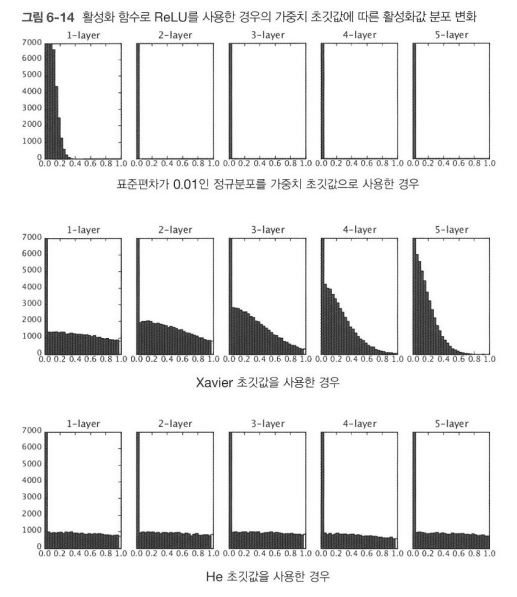   
- 결과를 보면 std = 0.01일 때의 각 층의 활성화값들은 아주 작은 값들
    - 신경망에 아주 작은 데이터가 흐른다는 것은 역전파 때 가중치의 기울기 역시 작아진다는 뜻 - 실제로 학습이 거의 이뤄지지 않을 것
- Xavier 초깃값 결과를 보면 층이 깊어지면서 치우침이 조금씩 커짐
    - 실제로 층이 깊어지면 활성화값들의 치우침도 커지고, 학습할 때 '기울기 소실'문제를 일으킴
- He 초깃값은 모든 층에서 균일하게 분포됨
    - 층이 깊어져도 분포가 균일하게 유지되기에 역전파 때도 적절한 값이 나올 것으로 기대할 수 있음


지금까지의 실험 결과를 바탕으로 활성화 함수로  
- sigmoid나 tanh 등의 S자 모양 곡선일 때는 Xavier 초깃값
- ReLU를 사용할 때는 He 초깃값

### MNIST 데이터셋으로 본 가중치 초깃값 비교

이번에는 '실제'데이터를 가지고 가중치의 초깃ㅂ가을 주는 방법이 신경망 학습에 얼마나 영향을 주는지 살펴봄   

===========iteration:0===========
std=0.01:2.3025278448252524
Xavier:2.3030821900429834
He:2.4461745732020117
===========iteration:100===========
std=0.01:2.3007241382667676
Xavier:2.2449242993793144
He:1.5584834044717164
===========iteration:200===========
std=0.01:2.3016564864738065
Xavier:2.1101687618806118
He:0.849182304218771
===========iteration:300===========
std=0.01:2.3032690694383846
Xavier:1.7882292930934893
He:0.5641365365919031
===========iteration:400===========
std=0.01:2.300742342602039
Xavier:1.33593071844882
He:0.5437413048076012
===========iteration:500===========
std=0.01:2.301752008388586
Xavier:0.8955357884129931
He:0.4242950412126285
===========iteration:600===========
std=0.01:2.3014016633310397
Xavier:0.8524356337542509
He:0.47546497820252964
===========iteration:700===========
std=0.01:2.3021706382114244
Xavier:0.610728218496928
He:0.3741274098568803
===========iteration:800===========
std=0.01:2.2996992418471627
Xavier:0.5026273865100864
He:0.2415748764698942

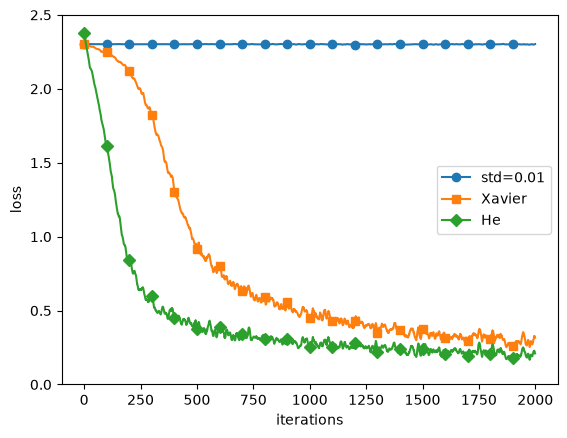

In [ ]:
# coding: utf-8
import sys, os
sys.path.append(os.pardir)

import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from codes.util import smooth_curve
from codes.multi_layer_net import MultiLayerNet
from codes.optimizer import SGD


# 0. MNIST 데이터 읽기
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

train_size = x_train.shape[0]
batch_size = 128
max_iterations = 2000


# 1. 실험용 설정
weight_init_types = {'std=0.01': 0.01, 'Xavier': 'sigmoid', 'He': 'relu'}
optimizer = SGD(lr=0.01)

networks = {}
train_loss = {}
for key, weight_type in weight_init_types.items():
    networks[key] = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100],
                                  output_size=10, weight_init_std=weight_type)
    train_loss[key] = []


# 2. 훈련 시작
for i in range(max_iterations):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]
    
    for key in weight_init_types.keys():
        grads = networks[key].gradient(x_batch, t_batch)
        optimizer.update(networks[key].params, grads)
    
        loss = networks[key].loss(x_batch, t_batch)
        train_loss[key].append(loss)
    
    if i % 100 == 0:
        print("===========" + "iteration:" + str(i) + "===========")
        for key in weight_init_types.keys():
            loss = networks[key].loss(x_batch, t_batch)
            print(key + ":" + str(loss))


# 3. 그래프 그리기
markers = {'std=0.01': 'o', 'Xavier': 's', 'He': 'D'}
x = np.arange(max_iterations)
for key in weight_init_types.keys():
    plt.plot(x, smooth_curve(train_loss[key]), marker=markers[key], markevery=100, label=key)
plt.xlabel("iterations")
plt.ylabel("loss")
plt.ylim(0, 2.5)
plt.legend()
plt.show()

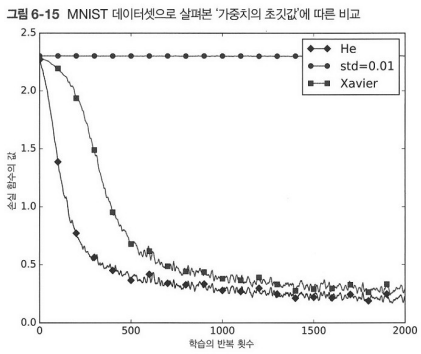   
- 이 실험은 층별 뉴런 수가 100개인 5층 신경망에서 활성화 함수로 ReLU를 사용함
- 그림에서 보듯 std = 0.01일 때는 학습이 전혀 이뤄지지 않음 - 순전파 때 너무 작은 값(0 근처로 밀집한 데이터)이 흐르기 때문
    - 그로 인해 역전파 때의 기울기도 작아져 가중치가 거의 갱신되지 않는 것
- 반대로 Xavier와 He 초깃값의 경우는 학습이 순조롭게 이뤄지고 있음
    - 학습 진도는 He 초깃값 쪽이 더 빠름

지금까지 살펴보았듯 가중치의 초깃값은 신경망 학습에 아주 중요한 포인트   
가중치의 초깃값에 따라 신경망 학습의 성패가 갈리는 경우가 많음   
초깃값의 중요성은 간과하기 쉬운 부분이지만, 어떤 일이든 시작(초깃값)이 중요한 법   

## 배치 정규화

**배치 정규화(Batch Nomalization)**: 각 층이 활성화를 적당히 퍼뜨리도록 '강제'한다는 아이디어에서 출발한 방법

### 배치 정규화 알고리즘

배치 정규화가 주목받는 이유   
- 학습을 빨리 진행할 수 있음(학습 속도 개선)
- 초깃값에 크게 의존하지 않음(골치 아픈 초깃값 선택 해결)
- 오버피팅을 억제(드롭아웃 등의 필요성 감소)

배치 정규화의 기본 아이디어는 각 층에서의 활성화값이 적당히 분포되도록 조정하는 것   
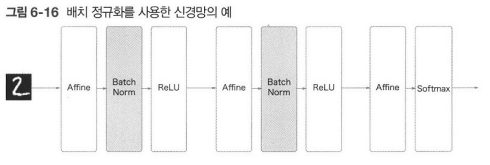   
- 그림과 같이 데이터 분포를 정규화하는 '배치 정규화(Batch Norm) 계층'을 신경망에 삽입함

배치 정규화는 그 이름과 같이 학습 시 미니배치를 단위로 정규화함   
구체적으로는 데이터 분포가 평균이 0, 분산 1이 되도록 정규화함   
수식으로는   
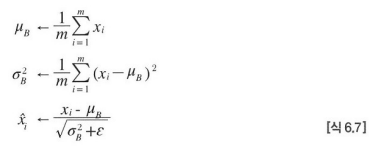
- 여기에는 미니배치 이라는 m개의 입력 데이터의 집합에 대해 평균 와 분산 을 구함
- 그리고 입력 데이터를 평균이 0, 분산이 1이 되게(적절한 분포가 되게) 정규화함
- 그리고 식에서 기호(epsilon, 엡실론)는 작은 값(10e-7 등)으로, 0으로 나누는 것을 예방하는 역할

위 식은 단순히 미니배치 입력 데이터 을 평균 0, 분산 1인 데이터 으로 변환하는 일을 함   
이 처리를 활성화 함수의 앞(혹은 뒤)에 삽입함으로써 데이터 분포가 덜 치우치게 할 수 있음

또, 배치 정규화 계층마다 이 정규화된 데이터에 고유한 확대(scale)와 이동(shift) 변환을 수행함   
수식으로는   
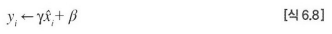   
- 이 식에서 을 담당함
- 두 값은 처음에는 각각 1, 0부터 시작하고, 학습하면서 적합한 값으로 조정해감

이 과정이 배치 정규화의 알고리즘   
이 알고리즘이 신경망에서 순전파 때 적용됨   
이를 계산 그래프로 그리면   
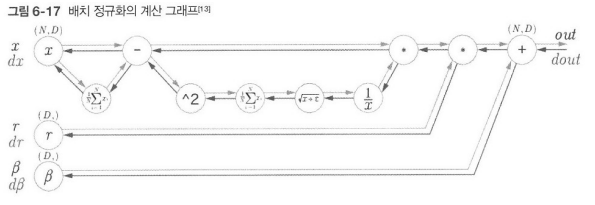   

배치 정규화의 역전파 유도는 다소 복잡하므로 여기에서는 설명하지 않지만   
위 그림과 같은 계산 그래프를 그려보면 비교적 쉽게 도출할 수 있음   
자세한 설명은 프레드릭 크레저트의 블로그에서 찾을 수 있음

### 배치 정규화의 효과

배치 정규화 계층을 사용한 실험 해보기   
우선 MNIST 데이터셋을 사용하여 배치 정규화 계층을 사용할 때와 사용하지 않을 때의 학습 진도가 어떻게 달라지는지 보면

epoch:0 | 0.104 - 0.137
epoch:1 | 0.105 - 0.174
epoch:2 | 0.112 - 0.316
epoch:3 | 0.124 - 0.447
epoch:4 | 0.132 - 0.538
epoch:5 | 0.138 - 0.604
epoch:6 | 0.146 - 0.649
epoch:7 | 0.146 - 0.678
epoch:8 | 0.148 - 0.716
epoch:9 | 0.154 - 0.75
epoch:10 | 0.164 - 0.773
epoch:11 | 0.174 - 0.789
epoch:12 | 0.187 - 0.805
epoch:13 | 0.2 - 0.82
epoch:14 | 0.211 - 0.841
epoch:15 | 0.234 - 0.85
epoch:16 | 0.238 - 0.865
epoch:17 | 0.249 - 0.872
epoch:18 | 0.265 - 0.879
epoch:19 | 0.276 - 0.888


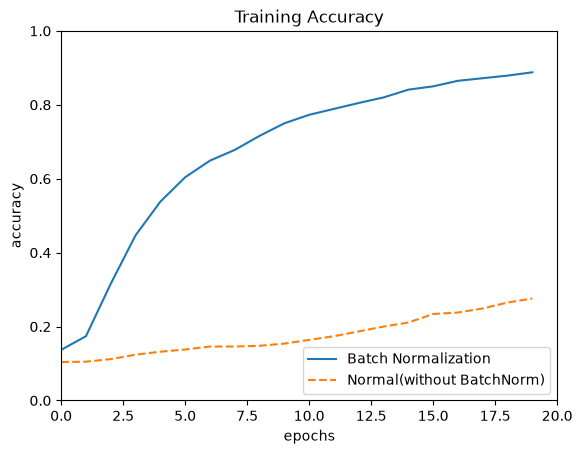

In [26]:
# coding: utf-8
import sys, os
sys.path.append(os.pardir)

import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from codes.multi_layer_net_extend import MultiLayerNetExtend
from codes.optimizer import SGD, Adam

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 학습 데이터를 줄임
x_train = x_train[:1000]
t_train = t_train[:1000]

max_epochs = 20
train_size = x_train.shape[0]
batch_size = 100
learning_rate = 0.01


def __train(weight_init_std):
    bn_network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100, 100, 100, 100], output_size=10, 
                                    weight_init_std=weight_init_std, use_batchnorm=True)
    network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100, 100, 100, 100], output_size=10,
                                weight_init_std=weight_init_std)
    optimizer = SGD(lr=learning_rate)
    
    train_acc_list = []
    bn_train_acc_list = []
    
    iter_per_epoch = max(train_size / batch_size, 1)
    epoch_cnt = 0
    
    for i in range(1000000000):
        batch_mask = np.random.choice(train_size, batch_size)
        x_batch = x_train[batch_mask]
        t_batch = t_train[batch_mask]
    
        for _network in (bn_network, network):
            grads = _network.gradient(x_batch, t_batch)
            optimizer.update(_network.params, grads)
    
        if i % iter_per_epoch == 0:
            train_acc = network.accuracy(x_train, t_train)
            bn_train_acc = bn_network.accuracy(x_train, t_train)
            train_acc_list.append(train_acc)
            bn_train_acc_list.append(bn_train_acc)
    
            print("epoch:" + str(epoch_cnt) + " | " + str(train_acc) + " - " + str(bn_train_acc))
    
            epoch_cnt += 1
            if epoch_cnt >= max_epochs:
                break
                
    return train_acc_list, bn_train_acc_list


# 그래프 그리기
weight_scale_list = np.logspace(0, -4, num=16)
x = np.arange(max_epochs)

train_acc_list, bn_train_acc_list = __train(weight_scale_list[4])
    
plt.title("Training Accuracy")
plt.plot(x, bn_train_acc_list, label='Batch Normalization', markevery=2)
plt.plot(x, train_acc_list, linestyle = "--", label='Normal(without BatchNorm)', markevery=2)
plt.ylim(0, 1.0)
plt.xlim(0, max_epochs)
plt.ylabel("accuracy")
plt.xlabel("epochs")
plt.legend(loc='lower right')
    
plt.show()

- 그림과 같이 배치 정규화가 학습을 빨리 진전시키고 있음

계속해서 초깃값 분포를 다양하게 줘가며 학습 진행이 어떻게 달라지는지 보면   
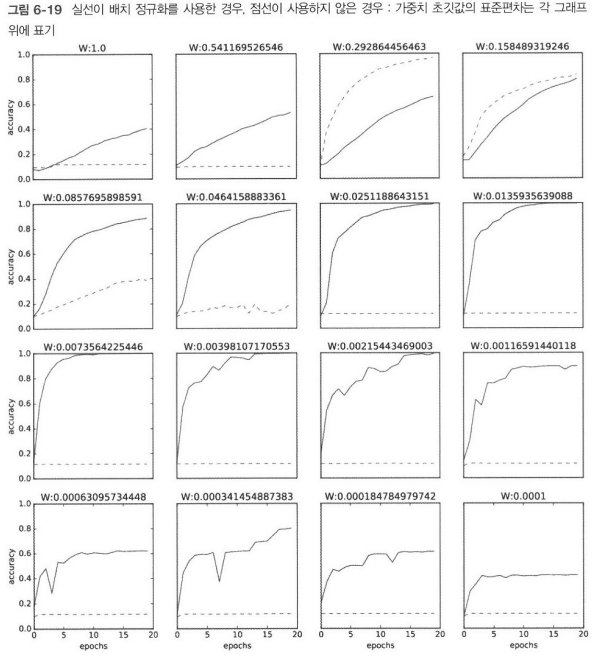   
- 거의 모든 경우에서 배치 정규화를 사용할 때의 학습 진도가 빠른 것으로 나타남
- 실제로 배치 정규화를 이용하지 않는 경우엔 초깃값이 잘 분포되어 있지 않으면 학습이 전혀 진행되지 않는 모습도 확인할 수 있음

배치 정규화를 사용하면 학습이 빨라지며, 가중치 초깃값에 크게 의존하지 않아도 됨   
배치 정규화는 이처럼 장점이 많으니 앞으로 다양한 분야에서 활약할 것

## 바른 학습을 위해

기계학습에서는 **오버피팅** 이 문제가 되는 일이 많음   
오버피팅: 신경망이 훈련 데이터에만 지나치게 적응되어 그 외에 데이터에는 제대로 대응하지 못하는 상태   
기계학습은 범용 성능을 지향함   
훈련 데이커에는 포함되지 않는, 아직 보지 못한 데이터가 주어져도 바르게 식별해내는 모델이 바람직함   
복잡하고 표현력이 높은 모델을 만들 수는 있지만, 그만큼 오버피팅을 억제하는 기술이 중요해지는 것

### 오버피팅

오버피팅이 주로 일어나는 경우
- 매개변수가 많고 표현력이 높은 모델
- 훈련 데이터가 적음

이번 절에서는 두 요건을 일부러 충족하여 오버피팅을 일으킴   
그러기 위해 원래 60,000개인 MNIST 데이터셋의 훈련 데이터 중 300개만 사용하고, 7층 네트워크를 사용해 네트워크의 복잡성을 높임   
각 층의 뉴런은 100개, 활성화 함수는 ReLU를 사용



epoch:0, train acc:0.13, test acc:0.1237
epoch:1, train acc:0.16333333333333333, test acc:0.1469
epoch:2, train acc:0.20333333333333334, test acc:0.1665
epoch:3, train acc:0.24666666666666667, test acc:0.1812
epoch:4, train acc:0.2733333333333333, test acc:0.1977
epoch:5, train acc:0.32, test acc:0.2115
epoch:6, train acc:0.36333333333333334, test acc:0.2292
epoch:7, train acc:0.4033333333333333, test acc:0.2492
epoch:8, train acc:0.41, test acc:0.2605
epoch:9, train acc:0.43333333333333335, test acc:0.2781
epoch:10, train acc:0.42333333333333334, test acc:0.2866
epoch:11, train acc:0.43333333333333335, test acc:0.2978
epoch:12, train acc:0.46, test acc:0.3193
epoch:13, train acc:0.4633333333333333, test acc:0.3276
epoch:14, train acc:0.48333333333333334, test acc:0.337
epoch:15, train acc:0.4633333333333333, test acc:0.3406
epoch:16, train acc:0.4766666666666667, test acc:0.3478
epoch:17, train acc:0.4866666666666667, test acc:0.3596
epoch:18, train acc:0.5366666666666666, test acc:0.

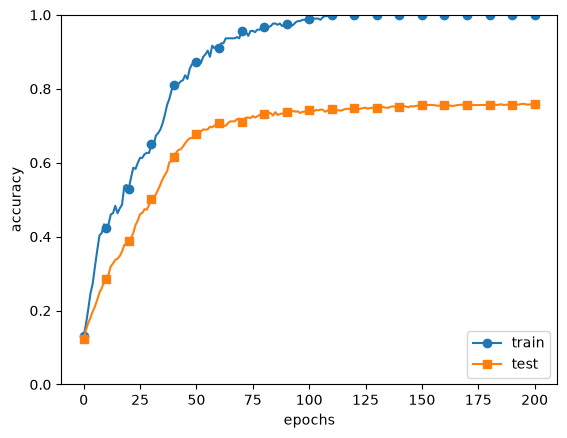

In [33]:
# coding: utf-8
import sys, os
sys.path.append(os.pardir)


import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from codes.multi_layer_net import MultiLayerNet
from codes.optimizer import SGD

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 과대적합을 재현하기 위해 학습 데이터 수를 줄임
x_train = x_train[:300]
t_train = t_train[:300]

network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10)
optimizer = SGD(lr=0.01)  # 학습률이 0.01인 SGD로 매개변수 갱신

max_epochs = 201
train_size = x_train.shape[0]
batch_size = 100

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)
epoch_cnt = 0

for i in range(1000000000):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    grads = network.gradient(x_batch, t_batch)
    optimizer.update(network.params, grads)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        print("epoch:" + str(epoch_cnt) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc))

        epoch_cnt += 1
        if epoch_cnt >= max_epochs:
            break


# 그래프 그리기==========
markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

훈련을 수행하는 코드
- 지금까지의 코드와 같지만 에폭마다 모든 훈련 데이터와 모든 시험 데이터 각각에서 정확도를 산출함
- train_acc_list와 test_acc_list에는 에폭 단위(모든 훈련 데이터를 한 번씩 본 단위)의 정확도를 저장함
- 이 두 리스트를 그래프로 그리면   
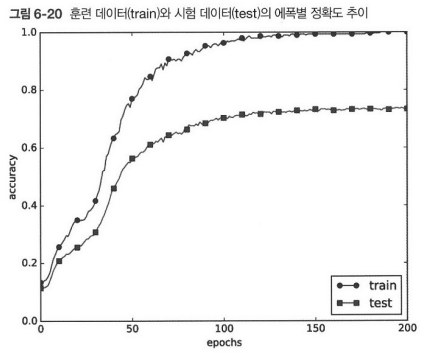   
- 훈련 데이터를 사용하여 측정한 정학도는 100 에폭을 지나는 무렵부터 거의 100%
- 그러나 시험 데이터에 대해서는 큰 차이를 보임
- 이처럼 정확도가 크게 벌어지는 것은 훈련 데이터에만 적응(fitting)해버린 결과
- 훈련 때 사용하지 않은 범용 데이터(시험 데이터)에는 제대로 대응하지 못하는 것을 이 그래프에서 확인할 수 있음

### 가중치 감소

**가중치 감소(weight decay)**: 오버피팅 억제용으로 예로부터 많이 이용해온 방법   
이는 학습 과정에서 큰 가중치에 대해서는 그에 상응하는 큰 페널티를 부과하여 오버피팅을 억제하는 방법   
원래 오버피팅은 가중치 매개변수의 값이 커서 발생하는 경우가 많기 때문

복습해보면   
신경망 학습의 목적은 손실 함수의 값을 줄이는 것   
- 예를 들어 가중치의 노름(norm)(L2 노름)을 손실 함수에 더함
- 그러면 가중치가 커지는 것을 억제할 수 있음
- 가중치를 W아 하면 L2 노름에 따른 가중치 감소는 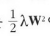이 되고, 이 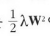을 손실 함수에 더함
- 는 정규화의 세기를 조절하는 하이퍼파라미터
- 를 크게 설정할수록 큰 가중치에 대한 페널티가 커짐
- 또 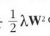의 앞쪽 1/2은 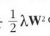의 미분 결과인 를 조정하는 역할의 상수

가중치 감소는 모든 가중치 각각의 손실 함수에 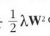를 더함   
따라서 가중치의 기울기를 구하는 계산에서는 그동안의 오차역전파법에 따른 결과에 정규화 항을 미분한 를 더함

> L2 노름은 각 원소의 제곱들을 더한 것에 해당   
> 가중치 이 있다면, L2 노름에서는 으로 계산할 수 있음   
> L2 노름 외에 L1 노름과  노름도 있음   
> L1 노름은 절댓값의 합, 즉 에 해당   
>  노름은 Max 노름이라고도 하며, 각 원소의 절댓값 중 가장 큰 것에 해당   
> 정규화 항으로 L2 노름, L1 노름,  노름 중 어떤 것도 사용할 수 있음   
> 각자 특징이 있는데, 이 책에서는 일반적으로 자주 쓰는 L2 노름만 구현함

그럼 실험을 해보면, 방금 수행한 실험에서  = 0.1로 가중치 감소를 적용함   
결과는   
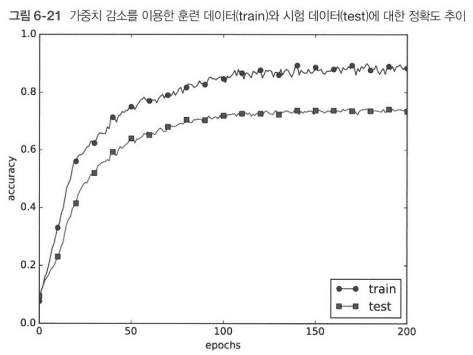   

epoch:0, train acc:0.11333333333333333, test acc:0.1032
epoch:1, train acc:0.13, test acc:0.1107
epoch:2, train acc:0.14, test acc:0.1162
epoch:3, train acc:0.18, test acc:0.1331
epoch:4, train acc:0.19666666666666666, test acc:0.1505
epoch:5, train acc:0.22333333333333333, test acc:0.1599
epoch:6, train acc:0.24333333333333335, test acc:0.1744
epoch:7, train acc:0.24666666666666667, test acc:0.1824
epoch:8, train acc:0.2633333333333333, test acc:0.1941
epoch:9, train acc:0.2733333333333333, test acc:0.2031
epoch:10, train acc:0.29, test acc:0.2083
epoch:11, train acc:0.32, test acc:0.2177
epoch:12, train acc:0.3466666666666667, test acc:0.2318
epoch:13, train acc:0.36333333333333334, test acc:0.2327
epoch:14, train acc:0.36333333333333334, test acc:0.2458
epoch:15, train acc:0.39, test acc:0.2546
epoch:16, train acc:0.4033333333333333, test acc:0.2612
epoch:17, train acc:0.42333333333333334, test acc:0.2773
epoch:18, train acc:0.43, test acc:0.2843
epoch:19, train acc:0.44666666666666

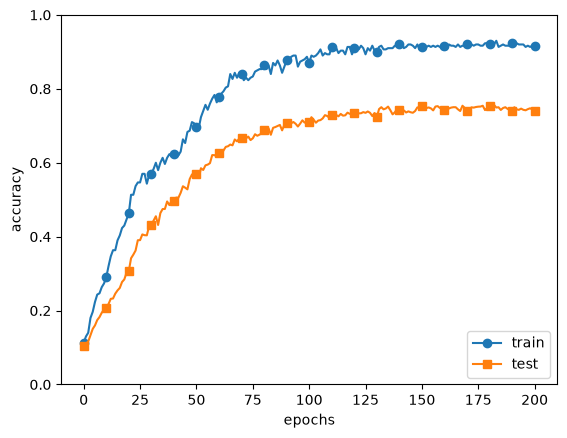

In [34]:
# coding: utf-8
import sys, os
sys.path.append(os.pardir)

import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from codes.multi_layer_net import MultiLayerNet
from codes.optimizer import SGD

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 과대적합을 재현하기 위해 학습 데이터 수를 줄임
x_train = x_train[:300]
t_train = t_train[:300]

weight_decay_lambda = 0.1 # 가중치 감쇠 설정

network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
                        weight_decay_lambda=weight_decay_lambda)
optimizer = SGD(lr=0.01) # 학습률이 0.01인 SGD로 매개변수 갱신

max_epochs = 201
train_size = x_train.shape[0]
batch_size = 100

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)
epoch_cnt = 0

for i in range(1000000000):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    grads = network.gradient(x_batch, t_batch)
    optimizer.update(network.params, grads)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        print("epoch:" + str(epoch_cnt) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc))

        epoch_cnt += 1
        if epoch_cnt >= max_epochs:
            break


# 그래프 그리기==========
markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

- 그림과 같이 훈련 데이터에 대한 정확도와 시험 데이터에 대한 정확도에는 여전히 차이가 있지만, 가중치 감소를 이용하지 않은 이전의 그림과 비교하면 그 차이가 줄었음
- 다시말해 오버피팅이 억제됐다는 소리
- 그리고 앞서와 달리 훈련 데이터에 대한 정확도가 100%(1.0)에 도달하지 못한 점도 주목해야 함

### 드롭아웃

앞 절에서는 오버피팅을 억제하는 방식으로 손실 함수에 가중치의 L2 노름을 더한 가중치 감소 방법을 설명함   
가중치 감소는 간단하게 구현할 수 있고 어느정도 지나친 학습을 억제할 수 있음   
그러나 신경망 모델이 복잡해지면 가중치 감소만으로는 대응하기 어려워짐   
이럴 때 흔히 **드롭아웃(Dropout)** 이라는 기법을 사용함   

- 드롭아웃은 뉴런을 임의로 삭제하면서 학습하는 방법
- 훈련 때 은닉층의 뉴런을 무작위로 골라 삭제함   
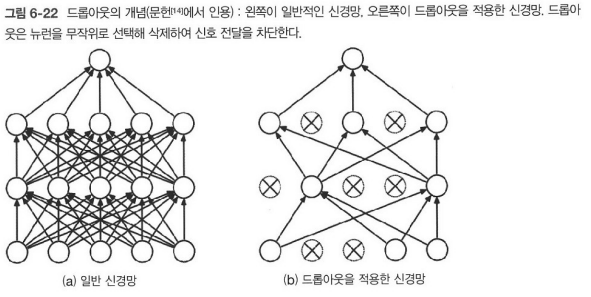   
- 삭제된 뉴런은 위 그림과 같이 신호를 전달하지 않게 됨
- 훈련 때는 데이터를 흘릴 때마다 삭제할 뉴런을 무작위로 선택하고, 시험 때는 모든 뉴런에 신호를 전달함
- 단, 시험 때는 각 뉴런의 출력에 훈련 때 삭제한 비율을 곱하여 출력함   

이제 드롭아웃을 구현할 차례   
다음 코드는 되도록 이해하기 쉽게 구현한 것   
순전파를 담당하는 forward 메서드에서는 훈련 때 (train_flg = True일 때)만 잘 계산해두면 시험 때는 단순히 데이터를 흘리기만 하면 됨   
삭제한 비율은 곱하지 않아도 좋음   
실제 딥러닝 프레임워크들도 비율을 곱하지 않음   
더 효율적인 구현이 궁금하면 체이너(Chainer) 프레임워크(http://chainer.org/)의 드롭아웃 구현을 참고

In [35]:
class Dropout:
    def __init__(self, dropout_ratio=0.5):
        self.dropout_ratio = dropout_ratio
        self.mask = None
    
    def forward(self, x, train_flg=True):
        if train_flg:
            self.mask = np.random.rand(*x.shape) > self.dropout_ratio
            return x * self.mask
        else:
            return x * (1.0 - self.dropout_ratio)
    
    def backward(self, dout):
        return dout * self.mask


- 여기에서의 핵심은 훈련 시에는 순전파 때마다 self.mask에 삭제할 뉴런을 False로 표시한다는 것
- self.mask는 x와 형상이 같은 배열을 무작위로 생성하고, 그 값이 dropout_ratio보다 큰 우너소만 True로 설정함
- 역전파 때의 동작은 ReLU와 같음
- 즉, 순전파 때 신호를 통과시키는 뉴런은 역전파 때도 신호를 그대로 통과시키고, 순전파 때 통과시키지 않은 뉴런은 역전파 때도 신호를 차단함

드롭아웃의 효과를 MNIST 데이터셋으로 확인해보기   
소스 코드에서는 Trainer라는 클래스를 이용하여 구현을 간소화함   

> codes/trainer.py에는 Trainer라는 클래스를 구현해둠   
> 이 클래스는 지금까지 해온 것과 같은 네트워크 학습을 대신 해줌   

train loss:2.3230088409834178
=== epoch:1, train acc:0.07333333333333333, test acc:0.0843 ===
train loss:2.322632474224246
train loss:2.30899872600425
train loss:2.2951692922538696
=== epoch:2, train acc:0.08666666666666667, test acc:0.0843 ===
train loss:2.3247065370637774
train loss:2.2916976769113226
train loss:2.315162325442433
=== epoch:3, train acc:0.08333333333333333, test acc:0.0843 ===
train loss:2.310160052171431
train loss:2.3148579432563103
train loss:2.311109216190883
=== epoch:4, train acc:0.08, test acc:0.0838 ===
train loss:2.301255183097445
train loss:2.322381255111265
train loss:2.294223694230458
=== epoch:5, train acc:0.08333333333333333, test acc:0.0851 ===
train loss:2.306337606688193
train loss:2.3031065252427894
train loss:2.3037257913957934
=== epoch:6, train acc:0.08666666666666667, test acc:0.0867 ===
train loss:2.300520454432465
train loss:2.3062814606021194
train loss:2.3121896004384532
=== epoch:7, train acc:0.08666666666666667, test acc:0.0886 ===
train lo

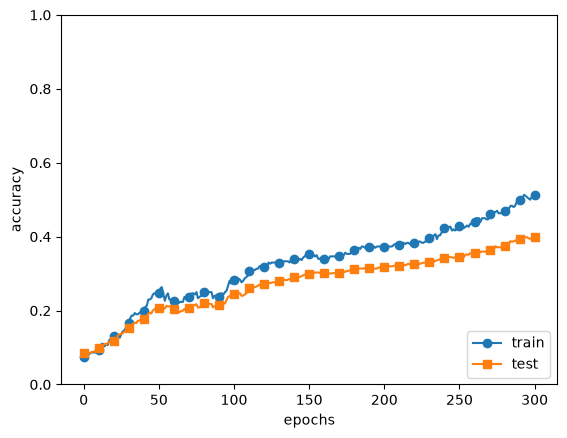

In [36]:
# coding: utf-8
import sys, os
sys.path.append(os.pardir)

import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from codes.multi_layer_net_extend import MultiLayerNetExtend
from codes.trainer import Trainer

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 오버피팅을 재현하기 위해 학습 데이터 수를 줄임
x_train = x_train[:300]
t_train = t_train[:300]

# 드롭아웃 사용 유무와 비율 설정 ========================
use_dropout = True  # 드롭아웃을 쓰지 않을 때는 False
dropout_ratio = 0.2
# ====================================================

network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100],
                              output_size=10, use_dropout=use_dropout, dropout_ration=dropout_ratio)
trainer = Trainer(network, x_train, t_train, x_test, t_test,
                  epochs=301, mini_batch_size=100,
                  optimizer='sgd', optimizer_param={'lr': 0.01}, verbose=True)
trainer.train()

train_acc_list, test_acc_list = trainer.train_acc_list, trainer.test_acc_list

# 그래프 그리기==========
markers = {'train': 'o', 'test': 's'}
x = np.arange(len(train_acc_list))
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

- 드롭아웃 실험은 앞의 실험과 마찬가지로 7층 네트워크 (각 층의 뉴런 수는 100개, 활성화 함수는 ReLU)를 써서 진행함   
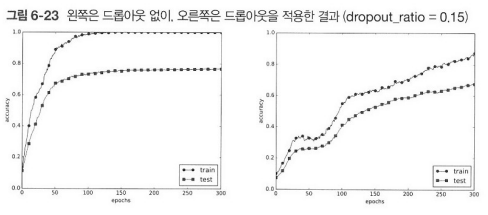   
- 그림과 같이 드롭아웃을 적용하니 훈련 데이터와 시험 데이터에 대한 정화도 차이가 줄어듬
- 또, 훈련 데이터에 대한 정확도가 100%에 도달하지도 않음   

이처럼 드롭아웃을 이용하면 표현력을 높이면서도 오버피팅을 억제할 수 있음   

> 기계학습에서는 **앙상블 학습(ensemble learning)** 을 애용함   
> 앙상블 학습은 개별적으로 학습시킨 여러 모델의 출력을 평균 내어 추론하는 방식   
> 신경망의 맥락에서 얘기하면, 가령 같은 (혹은 비슷한) 구조의 네트워크를 5개 준비하여 따로따로 학습시키고, 시험 때는 그 5개의 출력을 평균 내어 답하는 것   
> 앙상블 학습을 수행하면 신경망의 정확도가 몇% 정도 개선된다는 것이 실험적으로 알려져 있음   
> 앙상블 학습은 드롭아웃과 밀접함   
> 드롭아웃이 학습 때 뉴런을 무작위로 삭제하는 행위를 매번 다른 모델을 학습시키는 것으로 해석할 수 있기 때문   
> 그리고 추론 때는 뉴런의 출력에 삭제한 비유(이를테면 0.5 등)을 곱함으로써 앙상블 학습에서 여러 모델의 평균을 내는 것과 같은 효과를 얻는 것   
> 즉, 드롭아웃은 앙상블 학습과 같은 효과를 (대략) 하나의 네트워크로 구현했다고 생각할 수 있음

## 적절한 하이퍼파라미터 값 찾기

신경망에는 하이퍼파라미터가 자수 등장함   
여기서 하이퍼파라미터란
- 예를 들어 각 층의 뉴런 수, 배치 크기, 매개변수 갱신 시의 학습률과 가중치 감소 등

이러한 하이퍼파라미터의 값을 적절히 설정하지 않으면 모델의 성능이 크게 떨어지기도 함   
하이퍼파라미터의 값은 매우 중요하지만 그 값을 결정하기까지는 일반적으로 많은 시행착오를 겪음   

이번 절에서는 하이퍼파라미터의 값을 최대한 효율적으로 탐색하는 방법을 설명함

### 검증 데이터

지금까지는 데이터셋을 훈련 데이터와 시험 데이터라는 두 가지로 분리해 이용함   
훈련 데이터로는 학습을 하고, 시험 데이터로는 범용 성능을 평가함   
그렇게 해서 훈련 데이터에만 지나치게 적응되어 있지 않은지(오버피팅한 건 아닌지), 그리고 범용 성능은 어느 정도인지 같은 것을 평가할 수 있었음   

앞으로 하이퍼파라미터를 다양한 값으로 설정하고 검증할텐데,   
여기서 주의할 점은 하이퍼파라미터의 성능을 평가할 때는 시험 데이터를 사용해서는 안 된다는 것 - 매우 중요하지만 놓치기 쉬움   

같은 성능 평가인데 하이퍼파라미터가 대상일 때는 시험 데이터를 사용해서는 안되는 이유는?   
시험 데이터를 사용하여 하이퍼파라미터를 조정하면 하이퍼파라미터 값이 시험 데이터에 오퍼피팅되기 때문   
바꾸어 말하면, 하이퍼파라미터 값의 '좋음'을 시험 데이터로 확인하게 되므로 하이퍼파라미터의 값이 시험 데이터에만 적합하도록 조정되어 버림   
그렇게 되면 다른 데이터에는 적응하지 못하닌 범용 성능이 떨어지는 모델이 될 수 있음   

그래서 하이퍼파라미터를 조정할 때는 전용 확인 데이터가 필요 - **검증 데이터(validation data)**: 하이퍼파라미터의 적절성을 평가하는 데이터

> 훈련 데이터는 매개변수(가중치와 편향)의 학습에 이용하고, 검증 데이터는 하이퍼파라미터의 성능을 평가하는 데 이용함   
> 시험 데이터는 범용 성능을 확인하기 위해서 마지막에 (이상적으로는 한 번만) 이용함
> 훈련 데이터: 매개변수 학습   
> 검증 데이터: 하이퍼파라미터 성능 평가   
> 시험 데이터: 신경망의 범용 성능 평가

데이터셋에 따라서는 훈련, 검증, 시험 데이터를 미리 분리해둔 것도 있지만, MNIST 데이터셋은 훈련 데이터와 시험 데이터로만 분리해둠   
이런 경우엔 (필요하면) 사용자가 직접 데이터를 분리해야 함   
MNIST 데이터셋에서 검증 데이터를 얻는 가장 간단한 방법은 훈련 데이터 중 20% 정도를 검증 데이터로 먼저 분리하는 것   

코드로 보면

In [37]:
from codes.util import shuffle_dataset

(x_train, t_train), (x_test, t_test) = load_mnist()

# 훈련 데이터를 뒤섞음
x_train, t_train = shuffle_dataset(x_train, t_train)

# 20%를 검증 데이터로 분할
validation_rate = 0.20
validation_num = int(x_train.shape[0] * validation_rate)

x_val = x_train[:validation_num]
t_val = t_train[:validation_num]
x_train = x_train[validation_num:]
t_train = t_train[validation_num:]

- 이 코드는 훈련 데이터를 분리하기 전에 입력 데이터와 정답 레이블을 뒤섞음
- 데이터셋 안의 데이터가 치우쳐 있을지고 모르기 때문 (예턴대 숫자 '0'에서 '9'까지 순서대로 정렬되어 있을 수 있음)
- 여기서 사용한 shuffle_dataset 함수는 np.random.shuffle을 이용한 것

이어서 검증 데이터를 사용하여 하이퍼파라미터를 최적화하는 기법을 살펴봄

### 하이퍼파라미터 최적화

하이퍼파라미터를 최적화할 때의 핵심은 하이퍼파라미터의 '최적 값'이 존재하는 범위를 조금씩 줄여간다는 것   
범위를 조금씩 줄이려면 우선 대략적인 범위를 설정하고 그 범위에서 무작위로 하이퍼파라미터 값을 골라낸(샘플링) 후, 그 값으로 정확도를 평가함   
정확도를 잘 살피면서 이 작업을 여러 번 반복하며 하이퍼파라미터의 '최적 값'의 범위를 좁혀가는 것

> 신경망의 하이퍼파라미터 최적화에서는 그리드 서치(grid search) 같은 규칙적인 탐색보다는 무작위로 샘플링해 탐색하는 편이 좋은 결과를 낸다고 알려져 있음   
> 이는 최종 정확도에 미치는 영향력이 하이퍼파라미터마다 다르기 때문

하이퍼파라미터의 범위는 '대략적으로' 지정하는 것이 효과적   
실제로도 0.001에서 1,000 사이(10^-3 ~ 10^3)와 같이 '10의 거듭제곱' 단위로 범위를 지정함 - 이를 '로그 스케일(log scale)로 지정'한다고 함   

신경망의 하이퍼파라미터를 최적화할 때는 딥러닝 학습에는 오랜 시간 (예컨대 며칠이나 몇 주 이상)이 걸린다는 점을 기억해야 함   
따라서 나쁠 듯한 값은 일찍 포기하는 게 좋음   
그래서 학습을 위한 에폭을 작게 하여, 1회 평가에 걸리는 시간을 단축하는 것이 효과적   

지금까지의 내용을 정리하면   
- 0단계
    - 하이퍼파라미터 값의 범위를 설정
- 1단계
    - 설정된 범위에서 하이퍼파라미터의 값을 무작위로 추출함
- 2단계
    - 1단계에서 샘플링한 하이퍼파라미터 값을 사용하여 학습하고, 검증 데이터로 정확도를 평가함
- 3단계
    - 1단계와 2단계를 특정 횟수(100회 등) 반복하며, 그 정확도의 결과를 보고 하이퍼파라미터의 범위를 좁힘


이상을 반복하여 하이퍼파라미터의 범위를 좁혀가고, 어느 정도 좁아지면 그 압축한 범위에서 값을 하나 골라냄   
이것이 하이퍼파라미터를 최적화하는 하나의 방법

> 여기에서 설명한 하이퍼파라미터 최적화 방법은 실용적인 방법임   
> 하지만 과학이라기보다는 다분히 수행자의 '지혜'와 '직관'에 의존한다고 느낌이 듦   
> 더 세련된 기법을 원한다면 **베이즈 최적화(Bayesian optimization)**   
> 베이즈 최적화는 베이즈 정리를 중심으로 한 수핟 이론을 구사하여 더 엄밀하고 효율적으로 최적화를 수행함   
> 자세한 내용은 (Practical Bayesian Optimization of Machine Learning Algorithms) 논문 등을 참고

### 하이퍼파라미터 최적화 구현하기

MNIST 데이터셋을 사용하여 하이퍼파라미터를 최적화해보기   
여기에서는 학습률과 가중치 감소의 세기를 조절하는 계수(가중치 감소 계수)를 탐색하는 문제를 풀어봄   

앞의 내용대로, 하이퍼파라미터의 검증은 그 값을 0.001 ~ 1,000(10^-3 ~ 10^3) 사이 같은 로그 스케일 범위에서 무작위로 추출해 수행함   
이를 파이썬 코드로는 10 ** np.random.uniform(-3, 3)처럼 작성할 수 있음   
이 예에서는 가중치 감소 계수를 10^-8 ~ 10^-4, 학습률을 10^-6 ~ 10^-2 범위부터 시작함   
이 경우 하이퍼파라미터의 무작위 추출 코드는   

In [38]:
weight_decay = 10 ** np.random.uniform(-8, -4)
lr = 10 ** np.random.uniform(-6, -2)

- 이렇게 무작위로 추출한 값을 사용하여 학습을 수행함
- 그 후에는 여러 차례 다양한 하이퍼파라미터 값으로 학습을 반복하며 신경망에 좋을 것 같은 값이 어디에 존재하는지 관찰함

val acc:0.16 | lr:2.6274228102369295e-05, weight decay:1.0540400371626251e-05
val acc:0.09 | lr:5.704755814290654e-05, weight decay:1.1464714498115206e-05
val acc:0.12 | lr:0.00042322226196217164, weight decay:5.200958311914626e-07
val acc:0.09 | lr:8.365749499560211e-06, weight decay:4.532941303114864e-08
val acc:0.1 | lr:0.0005698527733216416, weight decay:6.271611244910704e-07
val acc:0.16 | lr:1.4614600348017376e-06, weight decay:7.846447230497523e-06
val acc:0.07 | lr:4.611657173069096e-05, weight decay:9.590663861619844e-06
val acc:0.07 | lr:6.654289143229933e-05, weight decay:6.097555785298088e-05
val acc:0.09 | lr:5.9450134729514066e-05, weight decay:1.9480268118084533e-06
val acc:0.13 | lr:1.5273037477900196e-05, weight decay:6.647573230941018e-05
val acc:0.07 | lr:1.44571420721376e-06, weight decay:2.0342042120024136e-06
val acc:0.07 | lr:7.0296954750681925e-06, weight decay:2.2120559554307607e-08
val acc:0.06 | lr:0.00010978878705079445, weight decay:1.441729646111348e-06
va

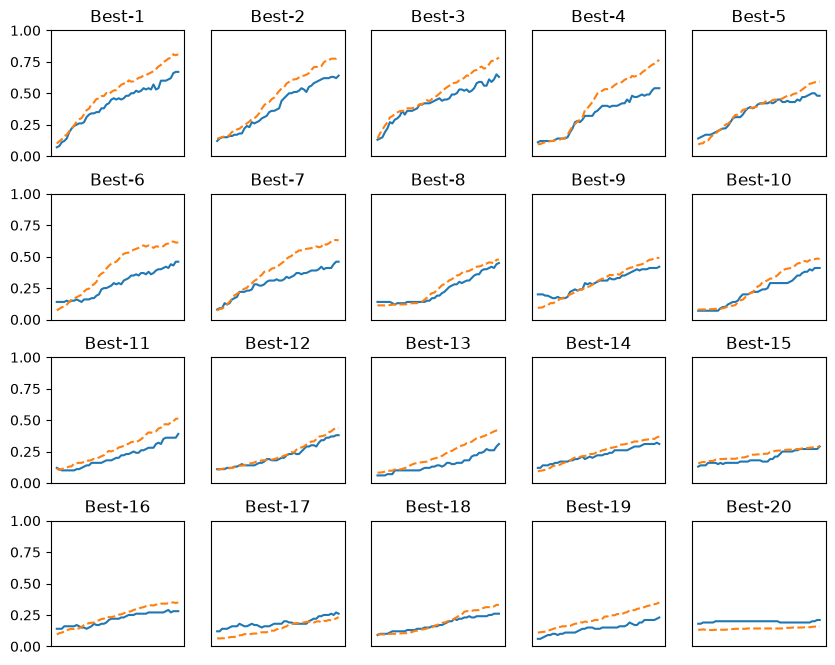

In [39]:
# coding: utf-8
import sys, os
sys.path.append(os.pardir)

import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from codes.multi_layer_net import MultiLayerNet
from codes.util import shuffle_dataset
from codes.trainer import Trainer

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 결과를 빠르게 얻기 위해 훈련 데이터를 줄임
x_train = x_train[:500]
t_train = t_train[:500]

# 20%를 검증 데이터로 분할
validation_rate = 0.20
validation_num = int(x_train.shape[0] * validation_rate)
x_train, t_train = shuffle_dataset(x_train, t_train)
x_val = x_train[:validation_num]
t_val = t_train[:validation_num]
x_train = x_train[validation_num:]
t_train = t_train[validation_num:]


def __train(lr, weight_decay, epocs=50):
    network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100],
                            output_size=10, weight_decay_lambda=weight_decay)
    trainer = Trainer(network, x_train, t_train, x_val, t_val,
                      epochs=epocs, mini_batch_size=100,
                      optimizer='sgd', optimizer_param={'lr': lr}, verbose=False)
    trainer.train()

    return trainer.test_acc_list, trainer.train_acc_list


# 하이퍼파라미터 무작위 탐색
optimization_trial = 100
results_val = {}
results_train = {}
for _ in range(optimization_trial):
    # 탐색한 하이퍼파라미터의 범위 지정===============
    weight_decay = 10 ** np.random.uniform(-8, -4)
    lr = 10 ** np.random.uniform(-6, -2)
    # ================================================

    val_acc_list, train_acc_list = __train(lr, weight_decay)
    print("val acc:" + str(val_acc_list[-1]) + " | lr:" + str(lr) + ", weight decay:" + str(weight_decay))
    key = "lr:" + str(lr) + ", weight decay:" + str(weight_decay)
    results_val[key] = val_acc_list
    results_train[key] = train_acc_list

# 그래프 그리기
print("=========== Hyper-Parameter Optimization Result ===========")
graph_draw_num = 20
col_num = 5
row_num = int(np.ceil(graph_draw_num / col_num))
i = 0

plt.figure(figsize=(10, 8))

for key, val_acc_list in sorted(results_val.items(), key=lambda x:x[1][-1], reverse=True):
    print("Best-" + str(i+1) + "(val acc:" + str(val_acc_list[-1]) + ") | " + key)

    plt.subplot(row_num, col_num, i+1)
    plt.title("Best-" + str(i+1))
    plt.ylim(0.0, 1.0)
    if i % 5: plt.yticks([])
    plt.xticks([])
    x = np.arange(len(val_acc_list))
    plt.plot(x, val_acc_list)
    plt.plot(x, results_train[key], "--")
    i += 1

    if i >= graph_draw_num:
        break

plt.subplots_adjust(wspace=0.2, hspace=0.3)    
plt.show()

가중치 감소 계수의 범위를 10^-8 ~ 10^-4, 학습률의 범위를 10^- 6 ~10^-2로 하여 실험하면 결과는   
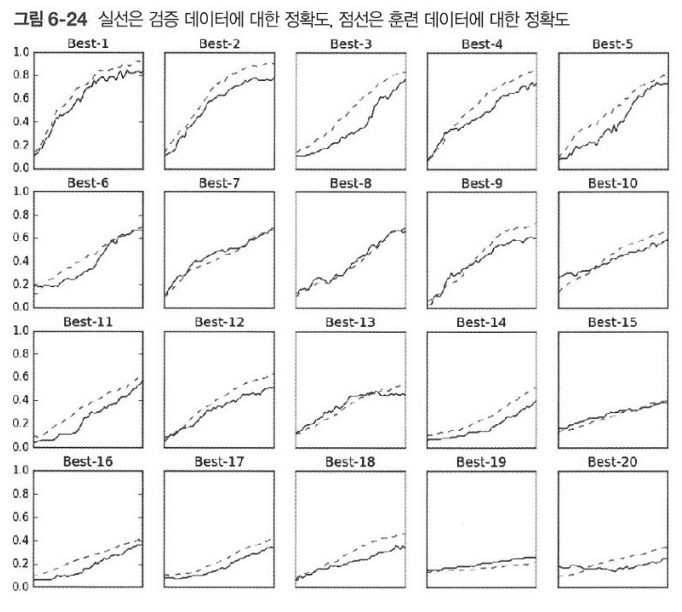   
- 그림은 검증 데이터의 학습 추이를 정확도가 높은 순서로 나열함
- 이를 보면 'Best-5' 정도까지는 학습이 순조롭게 진행되고 있음
- 이를 바탕으로 'Best-5'까지의 하이퍼파라미터의 값(학습률과 가중치 감소 계수)을 살펴보면   
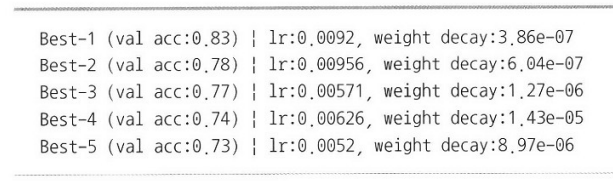   
- 이 결과를 보면 학습이 잘 진행될 때의 학습률은 0.001 ~ 0.01, 가중치 감소 계수는 10^-8 ~ 10^-6 정도라는 것을 알 수 있음
- 이처럼 잘될 것 같은 값의 범위를 관찰하고 범위를 좁혀나감
- 그런 다음 그 축소된 범위로 똑같은 작업을 반복하는 것
- 이렇게 적절한 값이 위치한 범위를 좁혀가다가 특정 단계에서 최종 하이퍼파라미터 값을 하나 선택함

## 정리

이번 장에서는 신경망 학습에 중요한 기술 몇 가지를 소개함
- 매개변수 갱신 방법
- 가중치의 초깃값을 설정하는 방법
- 배치 정규화와 드롭아웃

여기에서 배운 기술들은 최첨단 딥러닝에서도 자주 이용되고 있음

### 이번 장에서 배운 내용

- 매개변수 갱신 방법에는 확률적 경사 하강법(SGD) 외에도 모멘텀, Adagrad, Adam 등이 있음
- 가중치 초깃값을 정하는 방법은 올바른 학습을 하는 데 매우 중요
- 가중치의 초깃값으로는 'Xavier 초깃값'과 'He 초깃값'이 효과적
- 배치 정규화를 이용하면 학습을 빠르게 진행할 수 있으며, 초깃값에 영향을 덜 받게 됨
- 오버피팅을 억제하는 정규화 기술로는 가중치 감소와 드롭아웃이 있음
- 하이퍼파라미터 값 탐색은 최적 값이 존재할 법한 범위를 점차 좁히면서 하는 것이 효과적